# FinGuard — 01 Exploratory Data Analysis (Track A: benchmark)

**Data:** Anonymized credit-card transactions from the ULB/Kaggle `creditcardfraud` benchmark (284,807 raw rows, `Time`, `V1..V28`, `Amount`, `Class`). After deduplication the working set has **283,726 rows** with 473 fraud rows.

**Ground rules:** `V1..V28` are anonymous PCA components — no business meaning is invented for them. `hour_of_day` assumes a 24-hour cycle whose **phase is unknown**, so only relative patterns are interpreted.

## 1. Setup and data loading

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image as DispImage

import src.eda as eda
from src.config import (
    ENGINEERED_FEATURES_PATH, EDA_REPORTS_DIR, CREDITCARD_TARGET_COLUMN,
    CREDITCARD_AMOUNT_COLUMN, CREDITCARD_AMOUNT_LOG_COLUMN,
)

df = eda.load()
print('shape:', df.shape)

shape: (283726, 35)


## 2. Class imbalance

The dataset is highly imbalanced. Accuracy alone is meaningless here; later modeling phases use precision, recall, PR-AUC and alert-workload metrics.

,label,count,share_pct
0,legitimate,283253,99.83329
1,fraud,473,0.16671


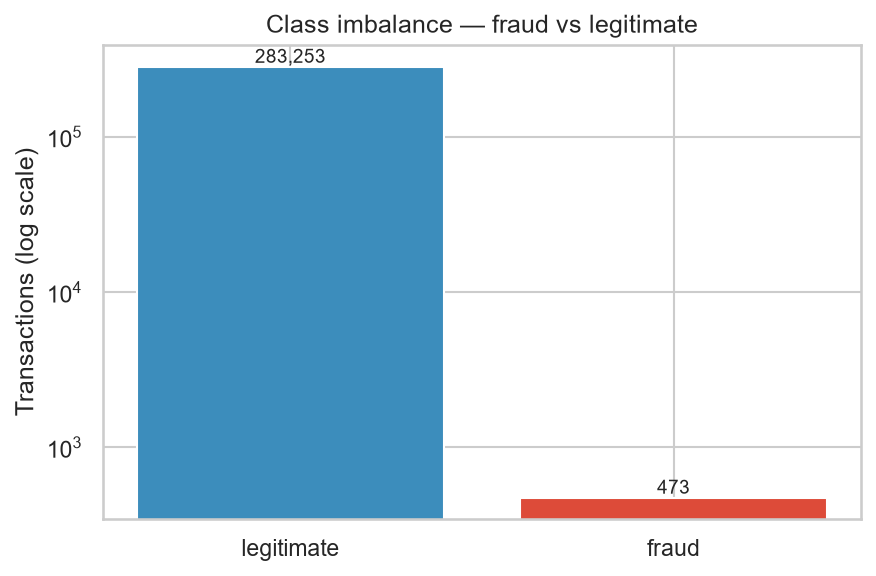

Fraud rate: 0.1667%


In [2]:
imbalance = eda.imbalance_summary(df)
display(imbalance)
eda.plot_class_balance(df, EDA_REPORTS_DIR)
display(DispImage((EDA_REPORTS_DIR / '01_class_balance.png').as_posix()))
print('Fraud rate: %.4f%%' % (100.0 * df[CREDITCARD_TARGET_COLUMN].mean()))

## 3. Transaction amount

Compare amount behaviour by label. Because amounts are right-skewed (max ~25.7k), log-transformed `amount_log` is plotted. Note the **mean vs median divergence**: fraud has a *higher* mean but a *lower* median than legitimate transactions.

,label,n,mean,std,min,p25,median,p75,p95,p99,max
0,Legitimate (0),283253,88.413575,250.379023,0.0,5.67,22.00,77.46,365.00,1018.0576,25691.16
1,Fraud (1),473,123.871860,260.211041,0.0,1.00,9.82,105.89,655.82,1364.1368,2125.87


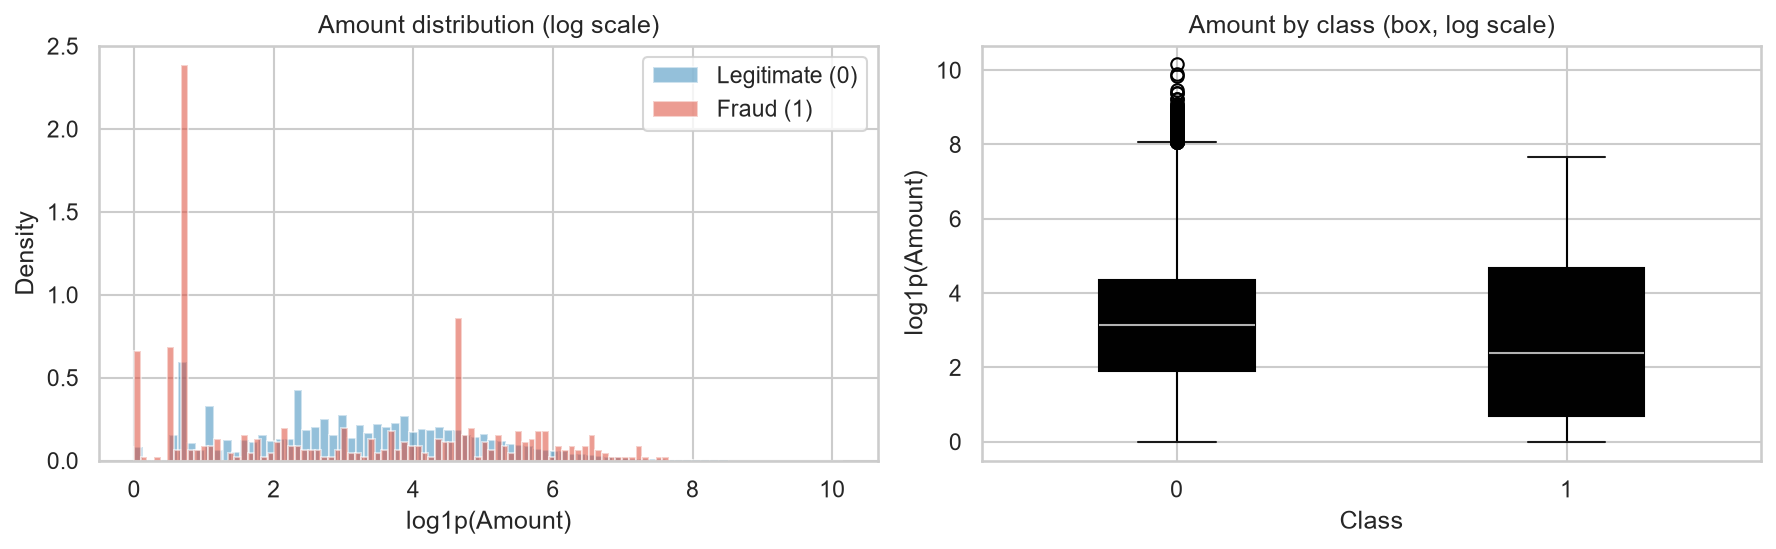

In [3]:
amt = eda.amount_stats(df)
display(amt)
eda.plot_amount_distribution(df, EDA_REPORTS_DIR)
display(DispImage((EDA_REPORTS_DIR / '02_amount_distribution.png').as_posix()))

## 4. Amount deciles

Fraud is not a 'big-amount' problem in this dataset. The smallest-amount decile has the **highest fraud rate**, and the largest decile is only mildly elevated (a mild U-shape).

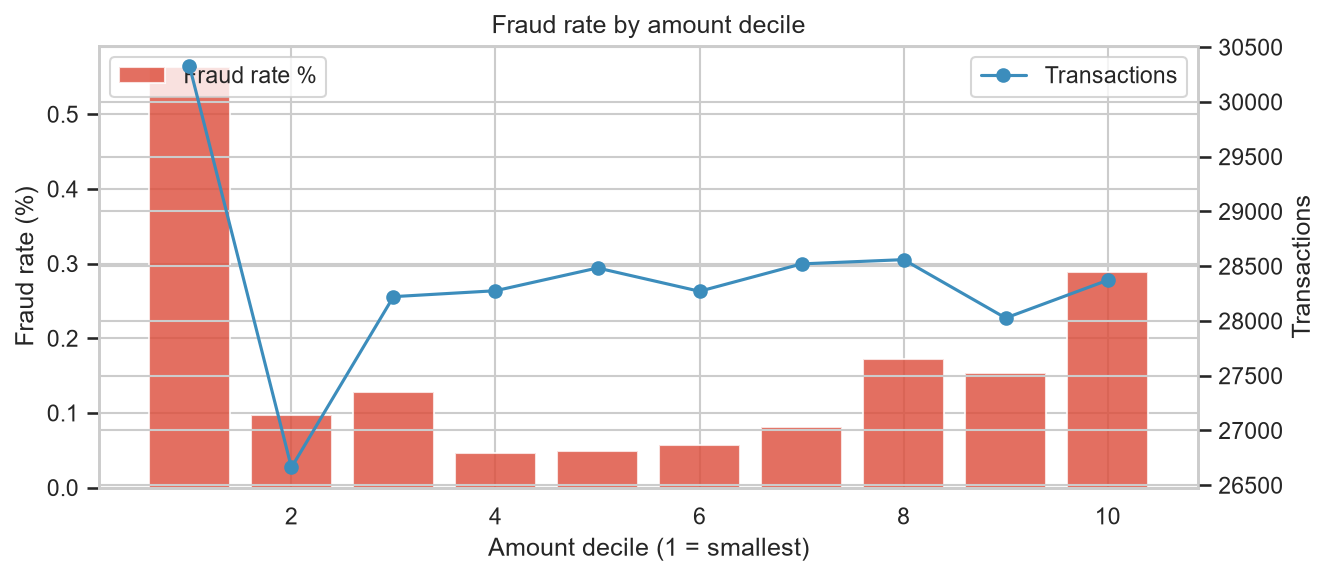

In [4]:
eda.plot_amount_deciles(df, EDA_REPORTS_DIR)
display(DispImage((EDA_REPORTS_DIR / '03_amount_decile_fraud_rate.png').as_posix()))

## 5. Time cycle (derived, phase unknown)

`hour_of_day = (Time % 86400) / 3600` assumes a 24h cycle over the observed ~48h window. Only the **shape** of the pattern is read: activity is lowest in the early hours of the cycle, where the fraud rate is highest relative to its own volume.

,hour_band,txns,fraud,fraud_rate_pct,lift
0,0.0,15163,64,0.422,2.532
1,3.0,8679,51,0.588,3.525
2,6.0,21547,41,0.190,1.141
3,9.0,49096,77,0.157,0.941
4,12.0,47221,57,0.121,0.724
5,15.0,48900,76,0.155,0.932
6,18.0,49230,65,0.132,0.792
7,21.0,43890,42,0.096,0.574


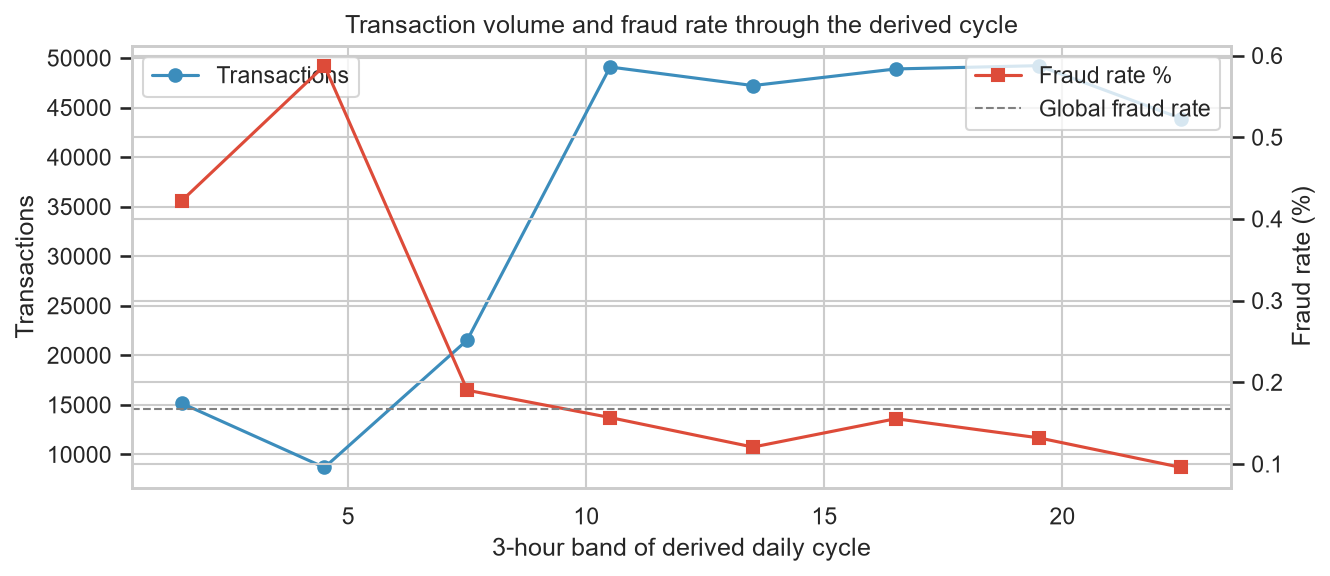

In [5]:
time_pat = eda.time_patterns(df)
display(time_pat.round(3))
eda.plot_time_patterns(df, EDA_REPORTS_DIR)
display(DispImage((EDA_REPORTS_DIR / '04_time_patterns.png').as_posix()))

## 6. Anonymous V-features

Rank the PCA components by standardized mean difference (Cohen's d) between classes, inspect the top separators, and check correlations. Results show several components are strong separators, which motivates the supervised models in later phases.

,feature,fraud_mean,legit_mean,cohens_d
0,V14,-6.8359,0.0117,-2.2281
1,V4,4.4726,-0.0104,1.9850
2,V12,-6.1033,0.0095,-1.8476
3,V11,3.7163,-0.0060,1.8441
4,V10,-5.4533,0.0077,-1.6025
5,V16,-4.0010,0.0078,-1.4449
6,V3,-6.7296,0.0129,-1.3503
7,V9,-2.5221,0.0026,-1.3253


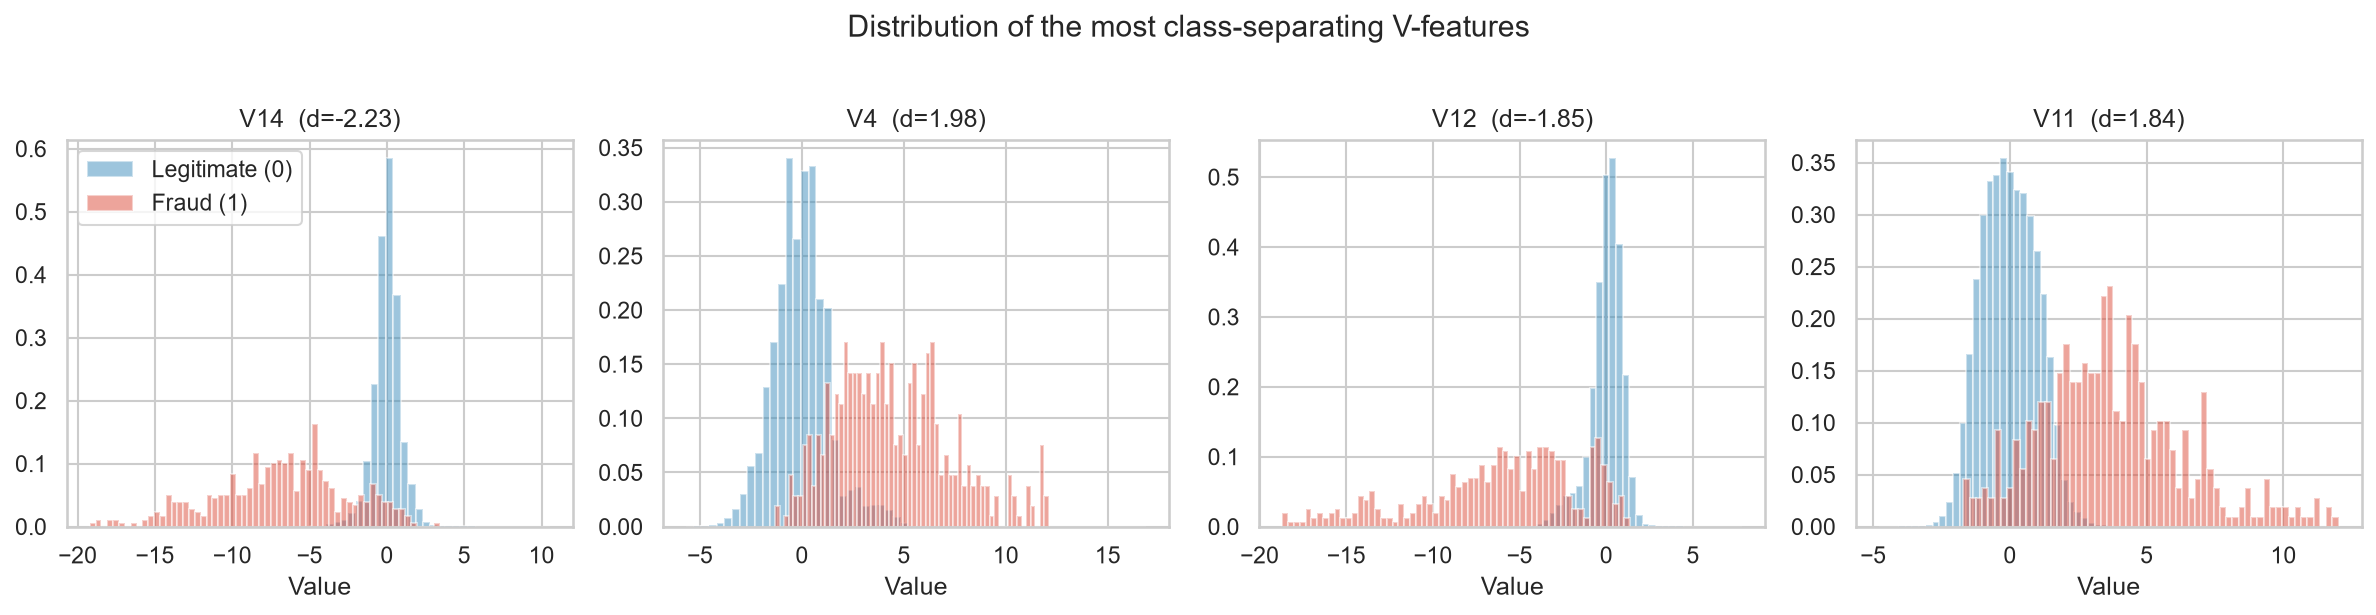

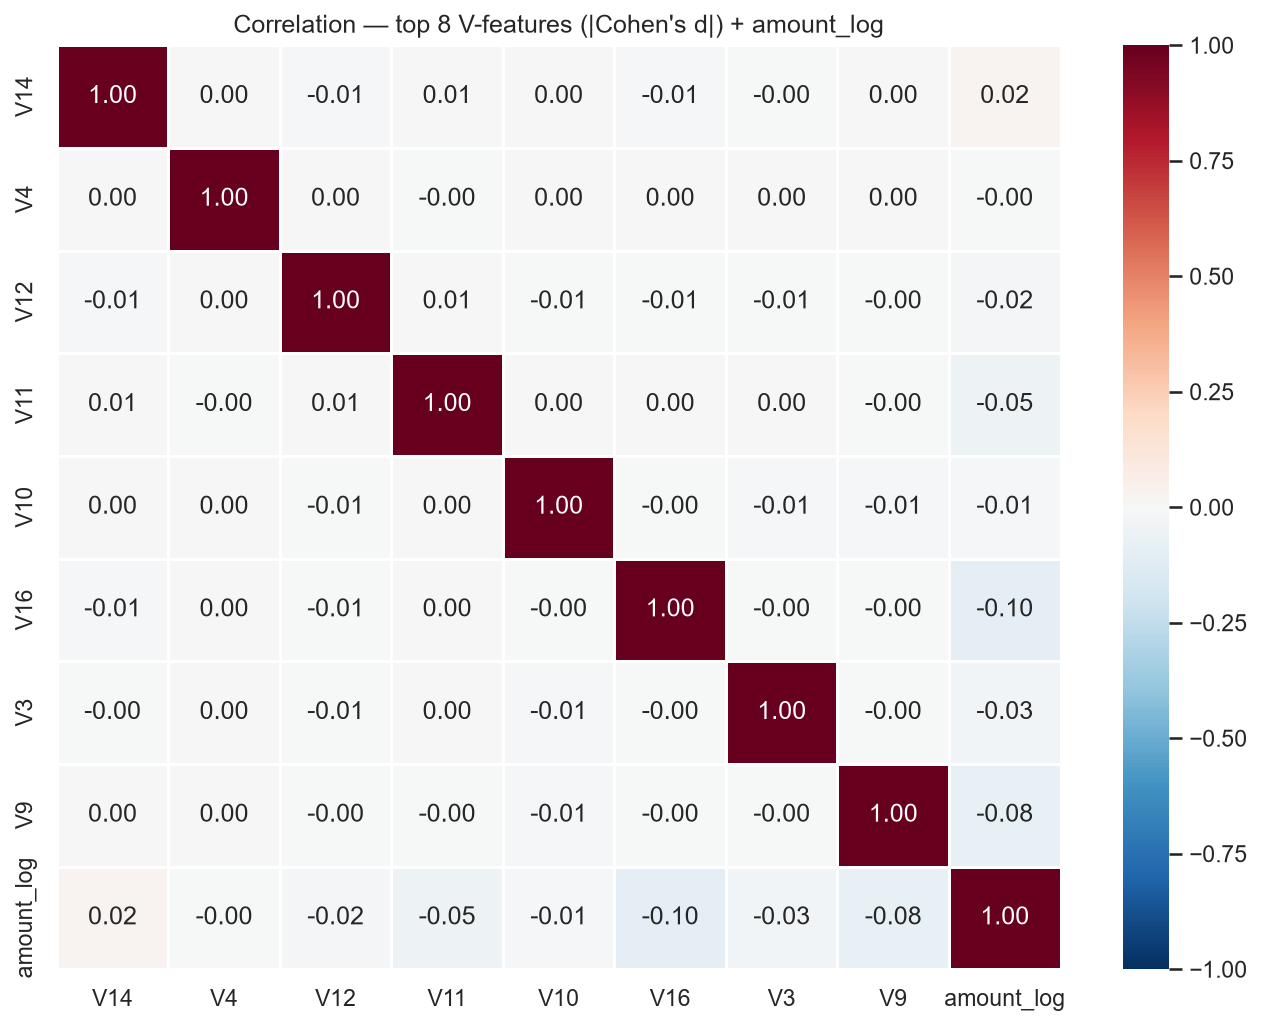

In [6]:
ranking = eda.cohens_d_ranking(df, top_n=8)
display(ranking.round(4))
eda.plot_top_features_by_class(df, EDA_REPORTS_DIR)
display(DispImage((EDA_REPORTS_DIR / '06_top_features_by_class.png').as_posix()))
eda.plot_feature_heatmap(df, EDA_REPORTS_DIR)
display(DispImage((EDA_REPORTS_DIR / '05_feature_heatmap.png').as_posix()))

## 7. Statistical comparison

Mann-Whitney U compares the class distributions without assuming normality. The difference in `amount` distributions is statistically significant, but the effect is small in practical terms — and it does **not** mean 'fraud = large amounts'.

In [7]:
tests = pd.DataFrame(eda.statistical_tests(df))
display(tests)
eda.save_summary_csv(df, EDA_REPORTS_DIR)

,variable,test,u_statistic,p_value,fraud_median,legit_median
0,amount,Mann-Whitney U,59517129.5,0.000027,9.820000,22.000000
1,amount_log,Mann-Whitney U,59517129.5,0.000027,2.381396,3.135494


WindowsPath('C:/Users/faiza/Documents/Default Project/FinGuard/reports/eda/feature_ranking.csv')

## 8. Summary of findings

1. Imbalance: 0.167% fraud — evaluation must use PR-based metrics.
2. Amount: fraud median 9.82 vs legit 22.00; fraud mean 123.87 vs 88.41. Mean/median divergence → report several statistics.
3. Deciles: smallest-amount decile carries the top fraud rate.
4. Cycle: early-cycle-hours show elevated relative fraud rate.
5. Features: V14, V4, V12, V11, V10 rank highest by |Cohen's d|.

### Limitations
- Anonymized PCs: patterns cannot be mapped to real-world causes.
- `hour_of_day` phase is unknown; absolute clock meanings are not claimed.
- Correlations ≠ causation; findings are dataset observations.
- Future-information hazards are avoided by fitting any scaler only on training data (modelling phase).